In [1]:
import matplotlib.pyplot as plt
import csv
import json
import numpy as np
import os

# Global vars for initialization
para = 3
nbins = 100
period = 500

class population():
    def __init__(self, para, nbins, period, Tissue=False):
        self.para = para
        self.nbins = nbins
        self.period = period
        
        # Store type for naming conventions
        self.type_str = "Tissue" if Tissue else "Cell"
        
        if Tissue:  
            self.csvfile = f"./populationTissue_period_{self.period}_measureTime_100000_C_Na_C_CaL_C_K1_{nbins-1}.csv"
            self.savefolder = f"./{round(self.period/1000,2)}HZ_result_Tissue"
            os.makedirs(self.savefolder, exist_ok=True)

        else:
            self.csvfile = f"./populationCell_period_{self.period}_measureTime_100000_C_Na_C_CaL_C_K1_{nbins-1}.csv"
            self.savefolder = f"./{round(self.period/1000,2)}HZ_result_Cell"
            os.makedirs(self.savefolder, exist_ok=True)


        # Data storage
        self.voltage = {}
        self.parameters = {}
        
        # Biomarker storage
        self.APD_90_lst = []
        self.plateau_duration_lst = []
        self.dv_dt_max_lst = []
        self.v_peak_lst = []
        self.RMP_lst = []
        self.dome_peak_lst = []
        
        self.get_csv()
        self.calculate_biomarkers()
        

    def get_APD(self, voltage, dt, APD_percentage=0.1): 
        # linear interpolation nested helper
        def linear_interpolation(y0, y1, x0, x1, x):
            return (y0 * (x1-x) + y1 * (x-x0)) / (x1-x0)

        APD_threshold = APD_percentage * (max(voltage) - min(voltage)) + min(voltage)
        APD_start_point = None
        APD_end_point = None
        start_apd = False
        APD_value = 0
        APD_start_error = -100
        APD_end_error = -100
        
        for j in range(len(voltage)):
            if start_apd == False and voltage[j] > APD_threshold:
                start_apd = True
                if j == 0:
                    APD_start_error = 0
                else:
                    APD_start_error = linear_interpolation(1, 0, voltage[j], voltage[j-1], APD_threshold)
                    APD_start_error = 1 - APD_start_error
                APD_start_point = j - 1 + APD_start_error
            
            if start_apd == True and voltage[j] <= APD_threshold: 
                start_apd = False
                APD_end_error = linear_interpolation(0, -1, voltage[j], voltage[j-1], APD_threshold)
                APD_end_point = j + APD_end_error
                APD_value += (APD_start_error + APD_end_error) * dt                
                APD_start_error = -100
                APD_end_error = -100
            
            if start_apd == True:
                APD_value += dt
        
        return APD_value, [APD_start_point, APD_end_point]

    def get_dvdt_max_and_plateau_duration(self, voltage, dt):
        dvdt_max = -1e6
        dvdt_plateau_lower_bound = -0.350
        plateau_duration = 0
        plateau_end_idx = None
        
        for j in range(1, len(voltage)):
            dvdt = (voltage[j] - voltage[j-1]) / dt
            plateau_duration += dt
            if dvdt > dvdt_max:
                dvdt_max = dvdt
            if dvdt < 0 and j > 100 and dvdt < dvdt_plateau_lower_bound:
                plateau_end_idx = j
                return dvdt_max, plateau_duration, plateau_end_idx
        return dvdt_max, plateau_duration, plateau_end_idx

    def get_AP(self, voltage_signal):
        APs = []
        starting_indexes = []
        current_AP = []
        in_AP = False
        
        for i in range(1, len(voltage_signal)):
            dv_dt = voltage_signal[i] - voltage_signal[i-1]
            if not in_AP:
                if dv_dt > 0.005 and voltage_signal[i-1] < 0:
                    in_AP = True
                    current_AP = [voltage_signal[i-1], voltage_signal[i]]
                    current_AP_start_idx = i - 1
                    starting_indexes.append(current_AP_start_idx)
            else:
                current_AP.append(voltage_signal[i])
                if i + 1 < len(voltage_signal):
                    next_dv_dt = voltage_signal[i+1] - voltage_signal[i]
                    if next_dv_dt > 0.005 and voltage_signal[i] < 0 and len(current_AP) > self.period * 3:
                        in_AP = False
                        APs.append(current_AP)
                        current_AP = []    
        return APs, starting_indexes

    def get_csv(self):
        prev_key = float(-1)
        
        with open(self.csvfile, 'r') as file:
            reader = csv.reader(file, delimiter=',')
            cur_v = []
            for row in reader:
                if len(row) == 1:
                    key = float(row[0].split('_')[1].replace('ID',''))
                    self.voltage[prev_key] = cur_v
                    prev_key = key
                    continue
                cur_v = [float(v) for v in row if v]
            self.voltage[prev_key] = cur_v
        
        with open(f"./2D-TNNP - Na - pace/population_params_{self.para}_N_{self.nbins}.json") as file:
            parameters_raw = json.load(file)
        
        self.parameters = {int(k['id']): {item[0]: round(item[1], 2) for item in k.items() if item[0] != 'id'} for k in parameters_raw}

    def calculate_biomarkers(self):
        self.APD_90_lst = []
        self.plateau_duration_lst = []
        self.dv_dt_max_lst = []
        self.v_peak_lst = []
        self.RMP_lst = []
        self.dome_peak_lst = []

        for key in sorted(self.voltage.keys()):
            APs, starting_indexes = self.get_AP(self.voltage[key])
            if not APs: continue
            
            last_AP = APs[-1]
            
            APD_90, APD_points = self.get_APD(last_AP, dt=0.2, APD_percentage=0.1)
            dvdt_max, plateau_duration, plateau_end_idx = self.get_dvdt_max_and_plateau_duration(last_AP, dt=0.2)
            
            v_peak = max(last_AP)
            RMP = min(last_AP)
            
            search_start = np.argmax(last_AP) + 10
            if search_start < len(last_AP):
                dome_peak = max(last_AP[search_start:])
            else:
                dome_peak = v_peak

            self.APD_90_lst.append(APD_90)
            self.plateau_duration_lst.append(plateau_duration)
            self.dv_dt_max_lst.append(dvdt_max)
            self.v_peak_lst.append(v_peak)
            self.RMP_lst.append(RMP)
            self.dome_peak_lst.append(dome_peak)

    # ---------------- PLOTTING FUNCTIONS ----------------

    def plot_biomarkers(self, show_plot=True):
        def plot_2d_biomarkers(ax, m1, m2, tolerance, m1_name, m2_name):
            ax.scatter(m1[1:], m2[1:], alpha=0.7, color='black')
            ax.axvline(x=m1[0]*(1+tolerance), color='w', linestyle='--', label='GT +10%')
            ax.axvline(x=m1[0]*(1-tolerance), color='w', linestyle='--', label='GT -10%')
            ax.axhline(y=m2[0]*(1+tolerance), color='w', linestyle='--', label='GT +10%')
            ax.axhline(y=m2[0]*(1-tolerance), color='w', linestyle='--', label='GT -10%')
            
            ax.set_facecolor('grey')
            ax.set_xlabel(m1_name, fontsize=12)
            ax.set_ylabel(m2_name, fontsize=12) 
            ax.set_xlim(xy_range[m1_name][0], xy_range[m1_name][1])
            ax.set_ylim(xy_range[m2_name][0], xy_range[m2_name][1])
            ax.margins(0.05)
            
            within_ids = [i for i in range(1, len(m1)) if (m1[0]*(1-tolerance) <= m1[i] <= m1[0]*(1+tolerance)) and (m2[0]*(1-tolerance) <= m2[i] <= m2[0]*(1+tolerance))]
            return within_ids

        

        biomarkers = {
            'APD90 (ms)': self.APD_90_lst,
            'Plateau Duration (ms)': self.plateau_duration_lst,
            'dV/dt Max (mV/ms)': self.dv_dt_max_lst,
            'Vm Peak (mV)': self.v_peak_lst,
            'RMP (mV)': self.RMP_lst,
            'Dome Peak (mV)': self.dome_peak_lst,
        }

        plot_pairs = [
            ('Vm Peak (mV)', 'RMP (mV)'), ('Vm Peak (mV)', 'APD90 (ms)'), ('Vm Peak (mV)', 'dV/dt Max (mV/ms)'),
            ('Vm Peak (mV)', 'Dome Peak (mV)'), ('Vm Peak (mV)', 'Plateau Duration (ms)'), ('RMP (mV)', 'APD90 (ms)'),
            ('RMP (mV)', 'dV/dt Max (mV/ms)'), ('RMP (mV)', 'Dome Peak (mV)'), ('RMP (mV)', 'Plateau Duration (ms)'),
            ('APD90 (ms)', 'dV/dt Max (mV/ms)'), ('APD90 (ms)', 'Dome Peak (mV)'), ('APD90 (ms)', 'Plateau Duration (ms)'),
            ('dV/dt Max (mV/ms)', 'Dome Peak (mV)'), ('dV/dt Max (mV/ms)', 'Plateau Duration (ms)'), ('Dome Peak (mV)', 'Plateau Duration (ms)'),
        ]
        
        xy_range = {
            'APD90 (ms)': (0, 800),
            'Plateau Duration (ms)': (0, 500),
            'dV/dt Max (mV/ms)': (0, 500),
            'Vm Peak (mV)': (-50, 60),
            'RMP (mV)': (-100, -50),
            'Dome Peak (mV)': (-50, 60),
        }

        tolerance = 0.1
        within_tolerance_ids_all = set()

        fig, axes = plt.subplots(5, 3, figsize=(12, 18))
        fig.tight_layout(pad=3.0)

        for i, pair in enumerate(plot_pairs):
            r = i // 3
            c = i % 3
            m1_name, m2_name = pair
            x_range, y_range = xy_range[m1_name], xy_range[m2_name]
            m1_data = biomarkers[m1_name]
            m2_data = biomarkers[m2_name]
            
            within_ids = plot_2d_biomarkers(axes[r, c], m1_data, m2_data, tolerance, m1_name, m2_name)
            within_tolerance_ids_all.update(within_ids)
            
        print(f"IDs within tolerance: {within_tolerance_ids_all}")
        plt.suptitle(f'Ground Truth tolerance {tolerance*100}%', fontsize=20, y=0.99)
        plt.tight_layout()
        
        # Always save
        plt.savefig(f"{self.savefolder}/TNNP_{round(self.period/1000,2)}HZ_{self.type_str}_Variation_biomarkers_2D.png", dpi=300)
        
        # Conditionally show
        if show_plot:
            plt.show()
        else:
            plt.close()

    def plot_individual_scatters(self, show_plot=True):
        metrics = [
            (self.APD_90_lst, "APD 90 (ms)", "APD90"),
            (self.plateau_duration_lst, "Plateau Duration (ms)", "PlateauDuration"),
            (self.dv_dt_max_lst, "dv/dt max (mV/ms)", "dv_dt_max"),
            (self.v_peak_lst, "V Peak (mV)", "VPeak"),
            (self.RMP_lst, "RMP (mV)", "RMP")
        ]
        
        sorted_keys = sorted(self.voltage.keys())
        
        for data, ylabel, filename_suffix in metrics:
            plt.figure(figsize=(10,6))
            plt.scatter(sorted_keys, data)
            plt.ylabel(ylabel, size=20)
            plt.xlabel("para_id", size=20)
            plt.title(f"{round(self.period/1000,2)} Hz pacing, at ~100000ms", size=20)
            plt.tight_layout()
            
            # Always save
            plt.savefig(f"{self.savefolder}/TNNP_{round(self.period/1000,2)}HZ_{self.type_str}_{filename_suffix}.png", dpi=300)
            
            # Conditionally show
            if show_plot:
                plt.show()
            else:
                plt.close()

    def plot_all_traces(self, show_plot=True):
        plt.figure(figsize=(30,10))
        for key in sorted(self.voltage.keys()):
            APs, _ = self.get_AP(self.voltage[key])
            if APs:
                last_AP = APs[-1]
                plt.plot(last_AP, label=f"Na={key:.1f}")
        plt.tight_layout()
        
        # Always save
        plt.savefig(f"{self.savefolder}/TNNP_{round(self.period/1000,2)}HZ_{self.type_str}_AllAPs.png", dpi=300)
        
        # Conditionally show
        if show_plot:
            plt.show()
        else:
            plt.close()

    def plot_single_detailed_AP(self, show_plot=True):
        last_key = sorted(self.voltage.keys())[-1]
        APs, _ = self.get_AP(self.voltage[last_key])
        if not APs: return
        last_AP = APs[-1]
        
        plt.figure(figsize=(10,10))
        plt.ylim(-100, 120)
        plt.xlim(0, 2000)
        plt.plot(last_AP)
        
        dvdt_max, plateau_duration, plateau_end_idx = self.get_dvdt_max_and_plateau_duration(last_AP, dt=0.2)
        APD, APD_boundary = self.get_APD(last_AP, dt=0.2, APD_percentage=0.1)
        
        if APD_boundary[0] is not None: plt.axvline(x=APD_boundary[0], color='g', linestyle='--', label='APD Start')
        if APD_boundary[1] is not None: plt.axvline(x=APD_boundary[1], color='r', linestyle='--', label='APD End')
        if plateau_end_idx is not None: plt.axvline(x=plateau_end_idx, color='b', linestyle='--', label='Plateau End')
        
        first_max_idx = np.argmax(last_AP)
        if first_max_idx + 10 < len(last_AP):
            second_max_idx = np.argmax(last_AP[first_max_idx+10:]) + first_max_idx + 10
            plt.axvline(x=second_max_idx, color='m', linestyle='--', label='Dome Peak')
        
        plt.legend(fontsize=20)
        plt.tight_layout()
        
        # Always save
        plt.savefig(f"{self.savefolder}/TNNP_{round(self.period/1000,2)}HZ_{self.type_str}_Na_AP.png", dpi=300)
        
        # Conditionally show
        if show_plot:
            plt.show()
        else:
            plt.close()

    def plot_AP_segment(self, show_plot=True):
        fig, axs = plt.subplots(11, 10, figsize=(20, 16))
        key_Na = -1
        max_key = len(self.voltage.keys())
        
        for i, ax in enumerate(axs.flat):
            if i < max_key:
                if key_Na in self.voltage:
                    APs, starting_indexes = self.get_AP(self.voltage[key_Na])
                    for start_idx in starting_indexes:
                        ax.plot(start_idx, self.voltage[key_Na][start_idx], 'ro', markersize=2)
                    
                    ax.plot(self.voltage[key_Na], color='C0')
                    ax.set_ylim(-100, 120)
                    
                    title_text = "default" if key_Na == -1 else f"{self.parameters.get(key_Na, 'Unk')}"
                    ax.set_title(title_text, fontsize=6)
                    
                    key_Na += 1
                    ax.set_xticks([])
                    ax.set_yticks([])
                else:
                    ax.text(0.5, 0.5, "Data Missing", transform=ax.transAxes, ha='center')
            ax.axis('off')
            
        plt.tight_layout()
        
        # Always save
        plt.savefig(f"{self.savefolder}/TNNP_{round(self.period/1000,2)}HZ_{self.type_str}_Variation_APs.png", dpi=300)
        
        # Conditionally show
        if show_plot:
            plt.show()
        else:
            plt.close()

    def plot_last_AP_features(self, show_plot=True):
        fig, axs = plt.subplots(11, 10, figsize=(20, 16))
        key_Na = -1
        max_key = len(self.voltage.keys())
        
        for i, ax in enumerate(axs.flat):
            if i < max_key:
                if key_Na in self.voltage:
                    APs, _ = self.get_AP(self.voltage[key_Na])
                    if APs:
                        last_AP = APs[-1]
                        ax.plot(last_AP)
                        
                        _, _, plateau_end_idx = self.get_dvdt_max_and_plateau_duration(last_AP, dt=0.2)
                        _, APD_boundary = self.get_APD(last_AP, dt=0.2, APD_percentage=0.1)
                        
                        if APD_boundary[0]: ax.axvline(x=APD_boundary[0], color='g', linestyle='--', label='Start')
                        if APD_boundary[1]: ax.axvline(x=APD_boundary[1], color='r', linestyle='--', label='End')
                        if plateau_end_idx: ax.axvline(x=plateau_end_idx, color='b', linestyle='--', label='Plateau')
                        
                        first_max_idx = np.argmax(last_AP)
                        if first_max_idx + 10 < len(last_AP):
                            second_max_idx = np.argmax(last_AP[first_max_idx+10:]) + first_max_idx + 10
                            ax.axvline(x=second_max_idx, color='m', linestyle='--', label='2nd Max')
                        
                        ax.set_ylim(-100, 120)
                        title_text = "default" if key_Na == -1 else f"{self.parameters.get(key_Na, 'Unk')}"
                        ax.set_title(title_text, fontsize=6)
                    
                    key_Na += 1
                    ax.set_xticks([])
                    ax.set_yticks([])
                else:
                    ax.text(0.5, 0.5, "Data Missing", transform=ax.transAxes, ha='center')
            ax.axis('off')

        plt.tight_layout()
        
        # Always save
        plt.savefig(f"{self.savefolder}/TNNP_{round(self.period/1000,2)}HZ_{self.type_str}_Variation_last_AP.png", dpi=300)
        
        # Conditionally show
        if show_plot:
            plt.show()
        else:
            plt.close()
    def run_all_plots(self, show_plot=True):
        self.plot_biomarkers(show_plot)
        self.plot_individual_scatters(show_plot)
        self.plot_all_traces(show_plot)
        self.plot_single_detailed_AP(show_plot)
        self.plot_AP_segment(show_plot)
        self.plot_last_AP_features(show_plot)

IDs within tolerance: {1, 4, 7, 8, 9, 10, 18, 19, 22, 25, 27, 34, 37, 42, 45, 47, 48, 49, 51, 53, 54, 57, 58, 60, 61, 64, 68, 69, 76, 77, 79, 82, 85, 88, 90, 91, 94, 95, 97}


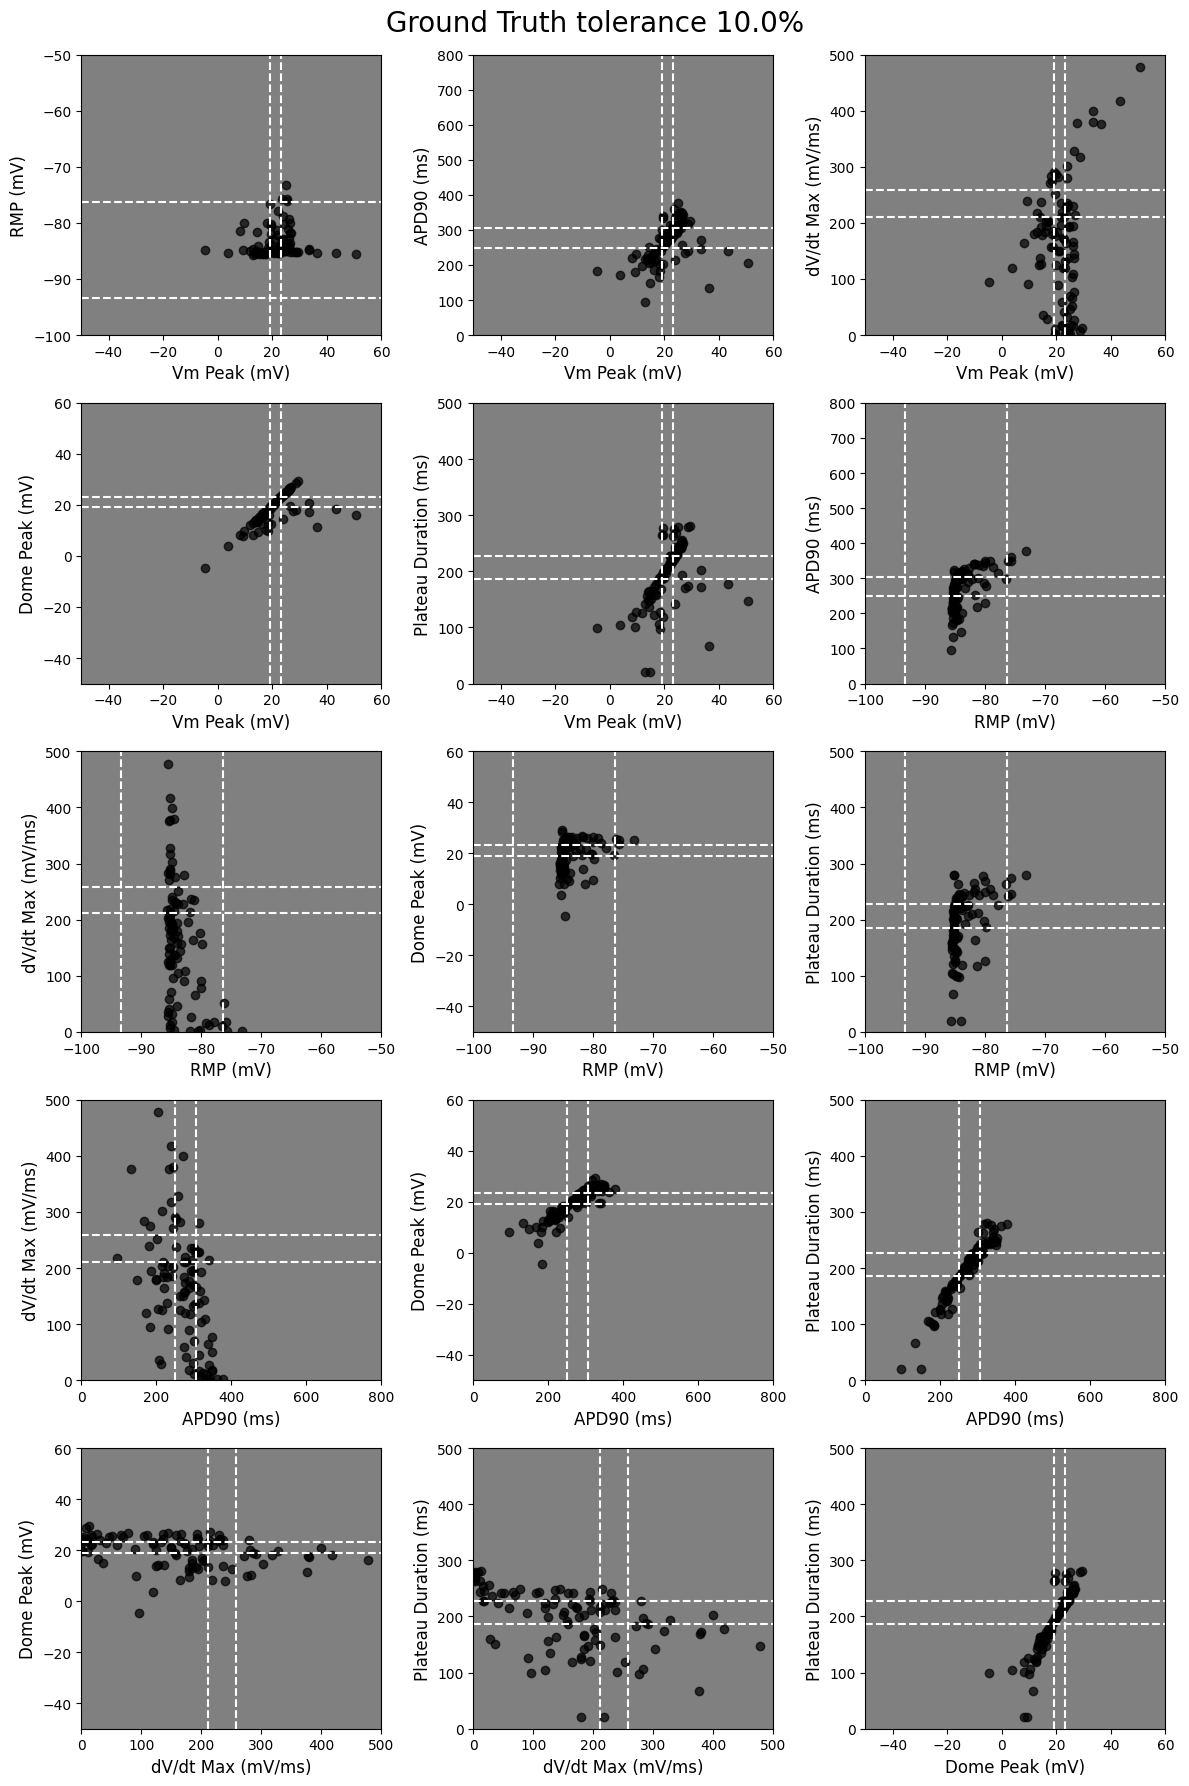

IDs within tolerance: {1, 4, 7, 8, 9, 10, 18, 19, 22, 25, 27, 34, 37, 42, 45, 47, 48, 49, 51, 53, 54, 57, 58, 60, 61, 64, 68, 69, 76, 77, 79, 82, 85, 88, 90, 91, 94, 95, 97}
IDs within tolerance: {4, 7, 8, 9, 13, 17, 18, 19, 22, 25, 27, 32, 34, 37, 42, 45, 47, 48, 49, 51, 53, 54, 57, 58, 60, 61, 62, 64, 65, 68, 76, 77, 79, 80, 82, 85, 88, 90, 91, 94, 95, 97}
IDs within tolerance: {4, 7, 8, 9, 19, 22, 25, 27, 34, 37, 42, 45, 47, 48, 49, 51, 53, 54, 57, 58, 60, 64, 68, 76, 77, 79, 82, 88, 90, 94, 97}
IDs within tolerance: {2, 4, 7, 8, 9, 18, 19, 21, 22, 25, 27, 32, 34, 37, 42, 45, 47, 48, 49, 51, 53, 54, 57, 58, 60, 64, 65, 68, 74, 76, 77, 79, 80, 82, 85, 86, 88, 90, 94, 97, 100}


In [3]:
para = 3
nbins = 100
period = 500
Tissue = True

population_instance = population(para, nbins, period, Tissue)
population_instance.plot_biomarkers(show_plot=True)
population_instance.run_all_plots(show_plot=False)

population(3,100,500,False).run_all_plots(show_plot=False)
population(3,100,1000,True).run_all_plots(show_plot=False)
population(3,100,1000,False).run_all_plots(show_plot=False)
